In [1]:
##### Creates scatterplot of pixel scale of predicted vs country-model results

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import rasterio
from scipy import stats
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import string
from scipy.stats import gaussian_kde

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# import model data 
capital_modeled = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD.tif")
labor_modeled = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs.tif")

# import country average data
capital_country_avg = rio.open_rasterio(f"{cd}/Results/Raster_model/country_avg_model/rescaled_capital_USD.tif")
labor_country_avg = rio.open_rasterio(f"{cd}/Results/Raster_model/country_avg_model/rescaled_jobs.tif")

# country boundaries 
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plot_predicted_country_avg"

In [3]:
### Data prep

target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

# Reproject rasters
rasters = {
    'capital_modeled': capital_modeled,
    'labor_modeled': labor_modeled,
    'capital_country_avg': capital_country_avg,
    'labor_country_avg': labor_country_avg,
}

rasters = {
    name: raster.rio.reproject(target_crs)
    for name, raster in rasters.items()
}

# Reassign variables
capital_modeled = rasters['capital_modeled']
labor_modeled = rasters['labor_modeled']
capital_country_avg = rasters['capital_country_avg']
labor_country_avg = rasters['labor_country_avg']

# Reproject boundaries
country_boundaries = country_boundaries.to_crs(target_crs)

### Calculate % differences

# Modeled vs country-average pairs
pairs = {
    'capital': (capital_modeled, capital_country_avg),
    'labor': (labor_modeled, labor_country_avg)
}

percent_dif = {}

for name, (modeled, country_avg) in pairs.items():
    modeled_log = np.log1p(modeled)
    country_avg_log = np.log1p(country_avg)

    percent_dif[name] = (
        (modeled_log - country_avg_log) / country_avg_log
    )

# Individual results
capital_percent_dif = percent_dif['capital']
labor_percent_dif = percent_dif['labor']

In [4]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

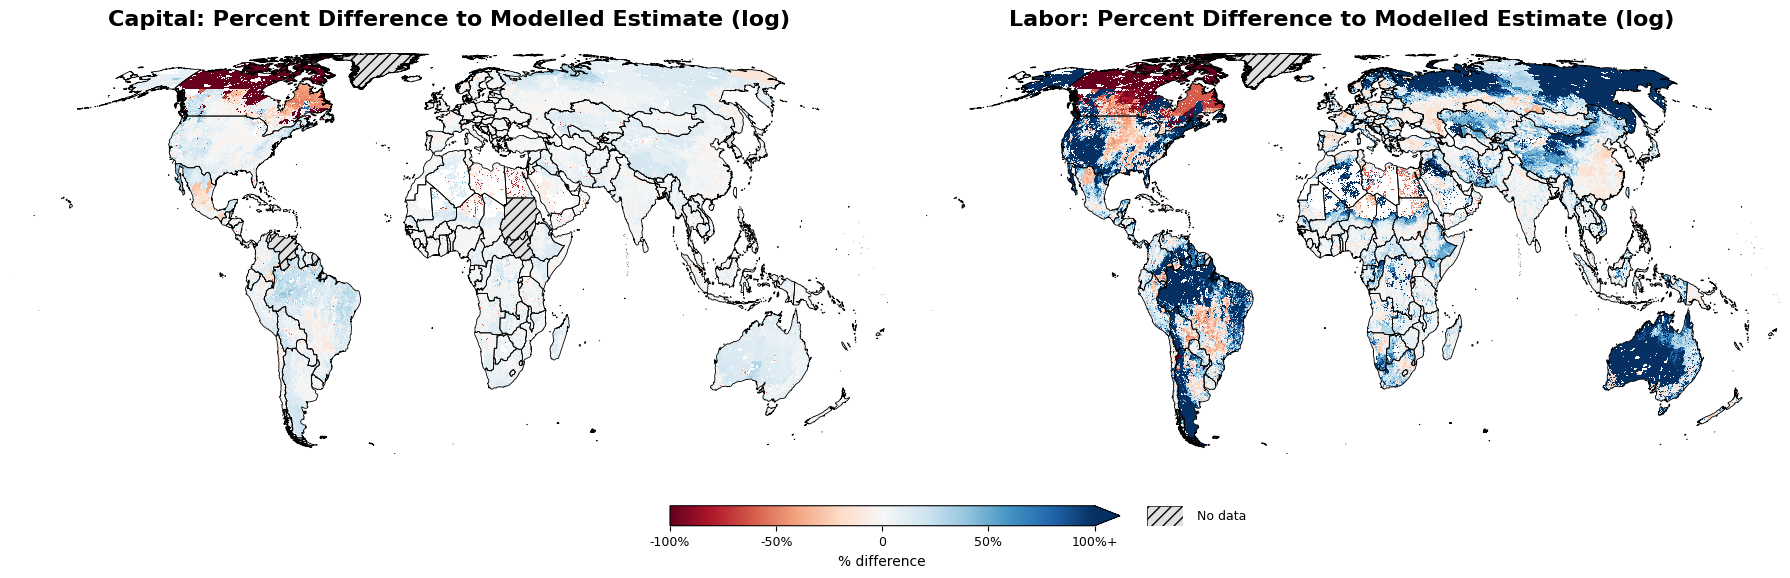

In [5]:
##### Global map of percent difference between country average and modelled capital/labor

# Prepare rasters
capital_plot = capital_percent_dif.squeeze()
labor_plot = labor_percent_dif.squeeze()
name = 'capital_labor_percent_diff'

bounds = [-1, -0.5, 0, 0.5, 1]
labels = ['-100%', '-50%', '0', '50%', '100%+']  # tick labels stop at 100%; triangle implies "+"

# Copy RdBu so we can set an "over" color without mutating the global colormap
rdbu = plt.get_cmap("RdBu").copy()
rdbu.set_over(rdbu(1.0))  # triangle color matches the darkest end of the ramp

no_data_color = "#e0e0e0"

# Create figure with 2 panels side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

panel_specs = [
    (axes[0], capital_plot, "has_capital_data", "Capital"),
    (axes[1], labor_plot, "has_labor_data", "Labor"),
]

ims = []
for ax, value_plot, has_data_col, panel_name in panel_specs:

    # Countries with no data (light grey fill with hatching, matches other map)
    country_boundaries[country_boundaries[has_data_col] == 0].plot(
        ax=ax,
        facecolor=no_data_color,
        edgecolor="none",
        hatch="///",
        zorder=0
    )

    # Country borders
    country_boundaries.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )

    # Raster
    im = value_plot.plot(
        ax=ax,
        cmap=rdbu,
        vmin=-1,
        vmax=1,
        add_colorbar=False,
        add_labels=False,
        zorder=1
    )
    ims.append(im)

    # Clip to country_boundaries
    minx, miny, maxx, maxy = country_boundaries.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_axis_off()
    ax.set_title(f"{panel_name}: Percent Difference to Modelled Estimate (log)", fontsize=16, weight='bold', pad=20)

# Finalize layout so both axes' real positions are available
plt.tight_layout()
fig.canvas.draw()

# --- Shared colorbar, bottom-center below both maps ---
left_pos = axes[0].get_position()
right_pos = axes[1].get_position()

cbar_width = 0.25
cbar_center_x = (left_pos.x0 + right_pos.x1) / 2
cbar_x0 = cbar_center_x - cbar_width / 2
cbar_y0 = min(left_pos.y0, right_pos.y0) - 0.09
cbar_height = 0.025

cbar_ax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, cbar_height])
cbar = fig.colorbar(
    ims[0],
    cax=cbar_ax,
    orientation="horizontal",
    extend='max',
    extendfrac=0.06,
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# --- "No data" swatch placed next to the colorbar ---
swatch_size = 0.02
gap = 0.015

legend_ax = fig.add_axes([
    cbar_x0 + cbar_width + gap,  # just right of the colorbar
    cbar_y0,                     # aligned with colorbar's bottom
    swatch_size,
    cbar_height
])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

fig.text(
    cbar_x0 + cbar_width + gap + swatch_size + 0.008,  # just right of the swatch
    cbar_y0 + cbar_height / 2,                           # vertically centered on swatch
    "No data",
    fontsize=9, va="center", ha="left"
)

plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

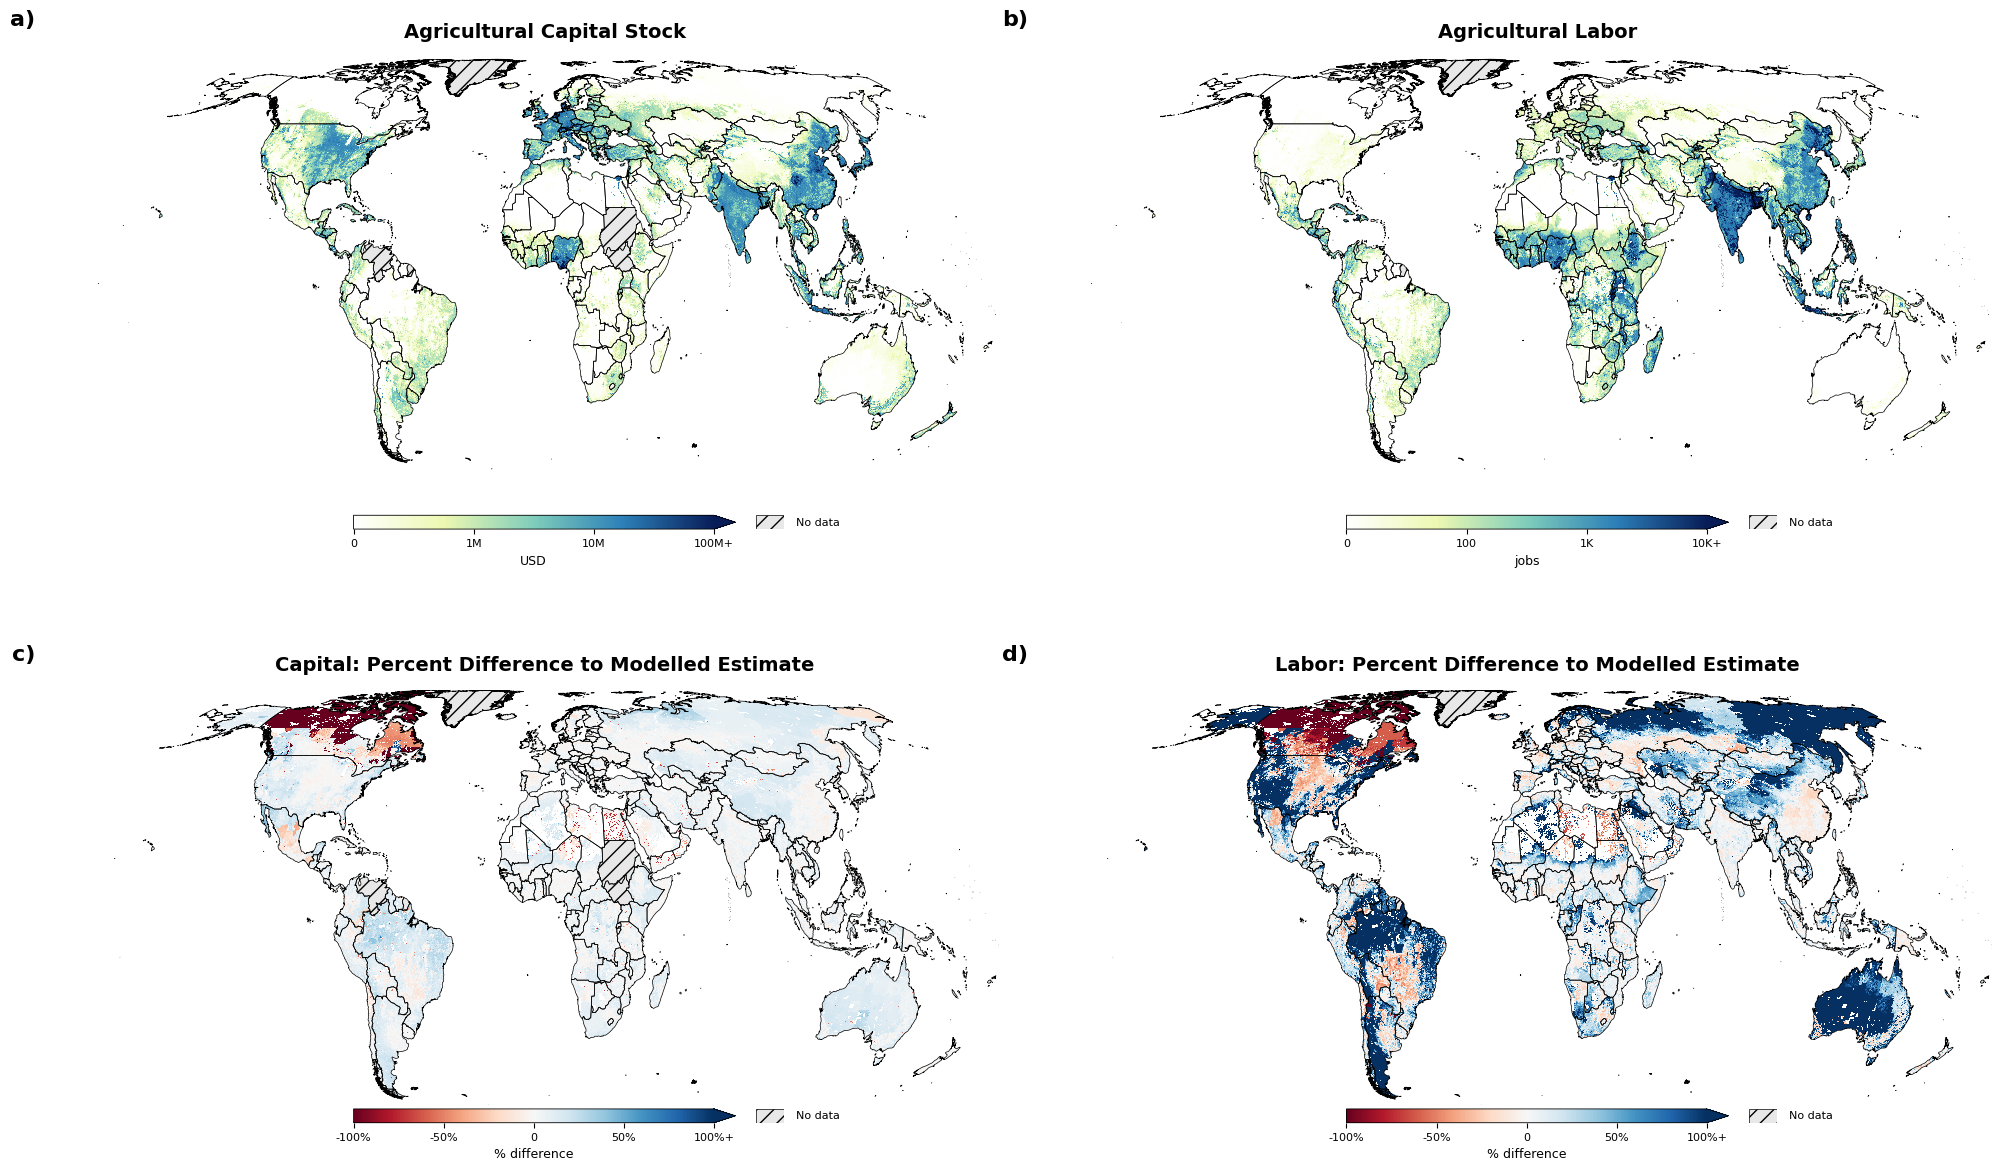

In [6]:
##### Combined figure: total maps + percent-difference maps (publication pass, no R2 inset)

import string

# ---------- helper: panel letter ----------
def add_panel_label(ax, label):
    ax.text(-0.06, 1.06, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='bottom', ha='right')


# ---------- helper: smooth axis transform (no seams, keeps absolute-value ticks) ----------
def asinh_forward(x, scale):
    return np.arcsinh(np.asarray(x) / scale)

def asinh_inverse(y, scale):
    return np.sinh(np.asarray(y)) * scale


def _to_flat_array(a):
    if hasattr(a, "values"):
        a = a.values
    a = np.asarray(a)
    return a.ravel()


# ---------- helper: total value map panel (sequential cmap) ----------
def plot_total_map(ax, value_plot, has_data_col, title):
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_ylgnbu",
        ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
    )
    custom_cmap.set_over("#081d58")

    no_data_color = "#e8e8e8"
    country_boundaries[country_boundaries[has_data_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="//", zorder=0
    )
    country_boundaries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, zorder=2)

    return custom_cmap


# ---------- helper: percent-difference map panel (diverging cmap) ----------
def plot_pct_diff_map(ax, value_plot, has_data_col, title):
    rdbu = plt.get_cmap("RdBu").copy()
    rdbu.set_over(rdbu(1.0))
    no_data_color = "#e8e8e8"

    country_boundaries[country_boundaries[has_data_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="//", zorder=0
    )
    country_boundaries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, zorder=2)

    im = value_plot.plot(
        ax=ax, cmap=rdbu, vmin=-1, vmax=1,
        add_colorbar=False, add_labels=False, zorder=1
    )

    minx, miny, maxx, maxy = country_boundaries.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_axis_off()
    ax.set_title(f"{title}: Percent Difference to Modelled Estimate", fontsize=14, weight='bold', pad=14)

    return im


# ---------- helper: add colorbar + no-data swatch BELOW a given map ----------
def add_map_legend(fig, ax, im, bounds, labels, cbar_label, no_data_color="#e8e8e8"):
    pos = ax.get_position()

    cbar_width = pos.width * 0.42
    cbar_x0 = pos.x0 + (pos.width - cbar_width) / 2
    cbar_y0 = pos.y0 - 0.015
    cbar_height = 0.012

    cax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, cbar_height])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='max', extendfrac=0.06)
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)
    cbar.outline.set_linewidth(0.6)

    swatch_size = 0.014
    gap = 0.01
    legend_ax = fig.add_axes([cbar_x0 + cbar_width + gap, cbar_y0, swatch_size, cbar_height])
    legend_ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=no_data_color, edgecolor="black",
                                   linewidth=0.5, hatch="//"))
    legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1)
    legend_ax.set_xticks([]); legend_ax.set_yticks([])
    legend_ax.axis("off")

    fig.text(cbar_x0 + cbar_width + gap + swatch_size + 0.006, cbar_y0 + cbar_height / 2,
              "No data", fontsize=8, va="center", ha="left")


# ================= BUILD FIGURE =================
fig, axes = plt.subplots(2, 2, figsize=(20, 11.5))

capital_map_bounds = [0, 1_000_000, 10_000_000, 100_000_000]
capital_map_labels = ['0', '1M', '10M', '100M+']

labor_map_bounds = [0, 100, 1_000, 10_000]
labor_map_labels = ['0', '100', '1K', '10K+']

# ---- Row 1: total capital/labor maps ----
def draw_total_map(ax, value_plot, has_data_col, title, bounds):
    cmap = plot_total_map(ax, value_plot, has_data_col, title)
    positions = np.linspace(0, 1, len(bounds))

    def forward(x):
        return np.interp(x, bounds, positions)

    def inverse(x):
        return np.interp(x, positions, bounds)

    norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

    im = value_plot.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False, add_labels=False, zorder=1)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, weight='bold', pad=14)
    return im

im_capital_total = draw_total_map(axes[0, 0], capital_modeled.squeeze(), "has_capital_data",
                                    "Agricultural Capital Stock", capital_map_bounds)
im_labor_total = draw_total_map(axes[0, 1], labor_modeled.squeeze(), "has_labor_data",
                                  "Agricultural Labor", labor_map_bounds)

# ---- Row 2: percent-difference maps ----
im_capital_pct = plot_pct_diff_map(axes[1, 0], capital_percent_dif.squeeze(), "has_capital_data", "Capital")
im_labor_pct = plot_pct_diff_map(axes[1, 1], labor_percent_dif.squeeze(), "has_labor_data", "Labor")

# panel letters
labels_alpha = list(string.ascii_lowercase[:4])
for ax, letter in zip(axes.flat, labels_alpha):
    add_panel_label(ax, f"{letter})")

# finalize layout FIRST — legends need true post-layout axes positions
plt.tight_layout()
fig.subplots_adjust(hspace=0.25)
fig.canvas.draw()

# row 1 legends
add_map_legend(fig, axes[0, 0], im_capital_total, bounds=capital_map_bounds, labels=capital_map_labels, cbar_label="USD")
add_map_legend(fig, axes[0, 1], im_labor_total, bounds=labor_map_bounds, labels=labor_map_labels, cbar_label="jobs")

# row 2 legends
add_map_legend(fig, axes[1, 0], im_capital_pct,
               bounds=[-1, -0.5, 0, 0.5, 1], labels=['-100%', '-50%', '0', '50%', '100%+'],
               cbar_label="% difference")
add_map_legend(fig, axes[1, 1], im_labor_pct,
               bounds=[-1, -0.5, 0, 0.5, 1], labels=['-100%', '-50%', '0', '50%', '100%+'],
               cbar_label="% difference")

plt.show()

fig.savefig(f"{fd}/capital_labor_combined_panel.png", dpi=300, bbox_inches='tight')